YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
c:\Users\ASIS VIVOBOOJK\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\ASIS VIVOBOOJK\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step


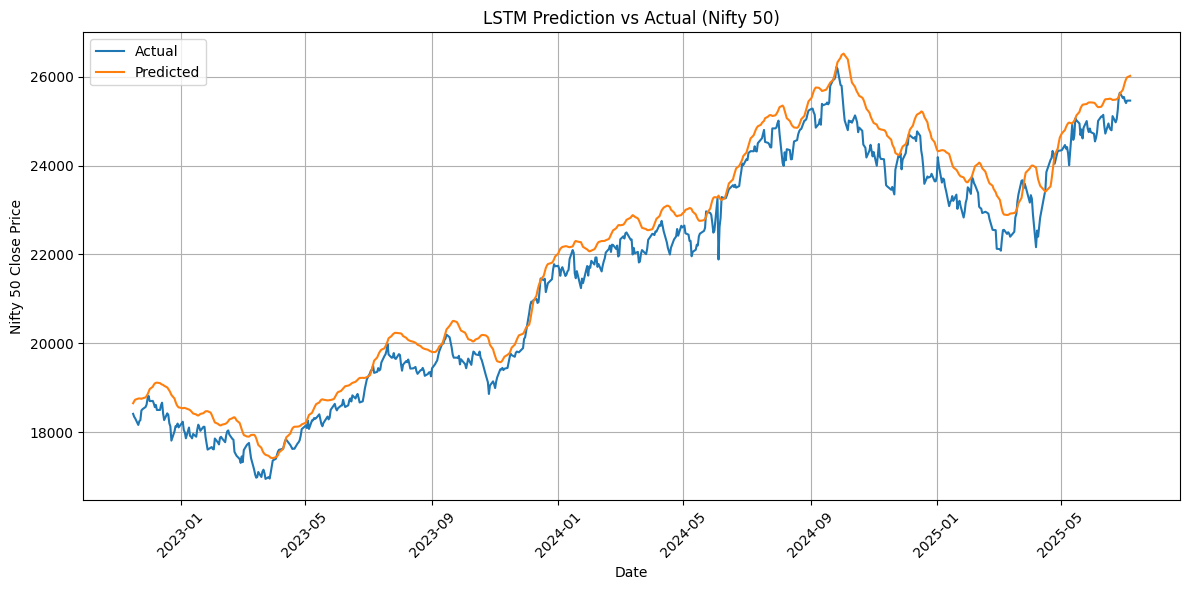

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


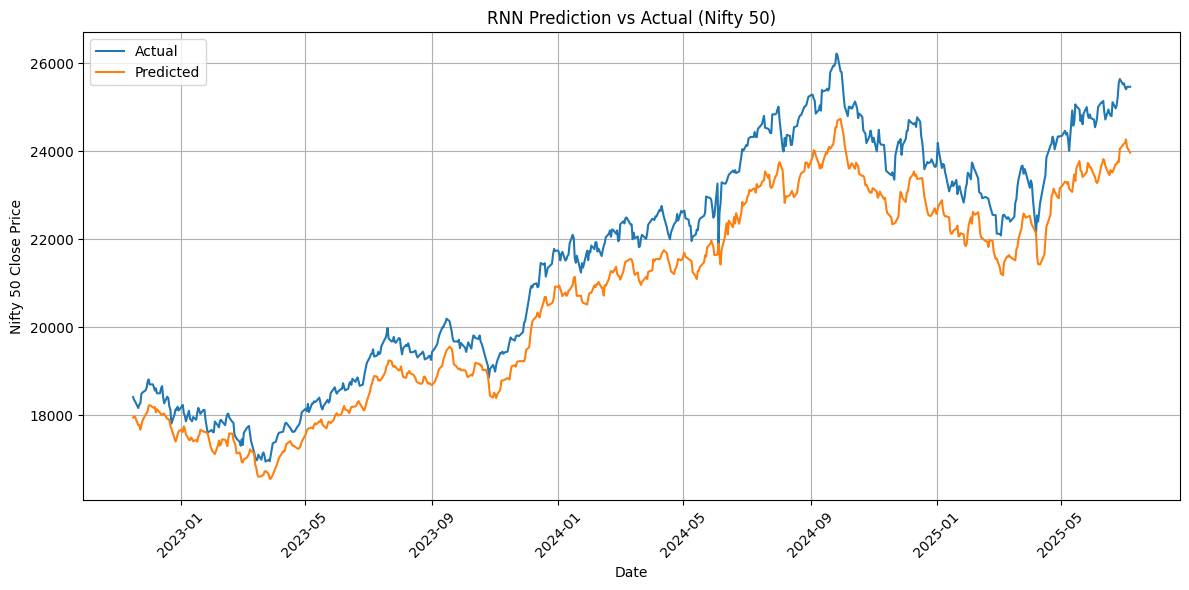

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


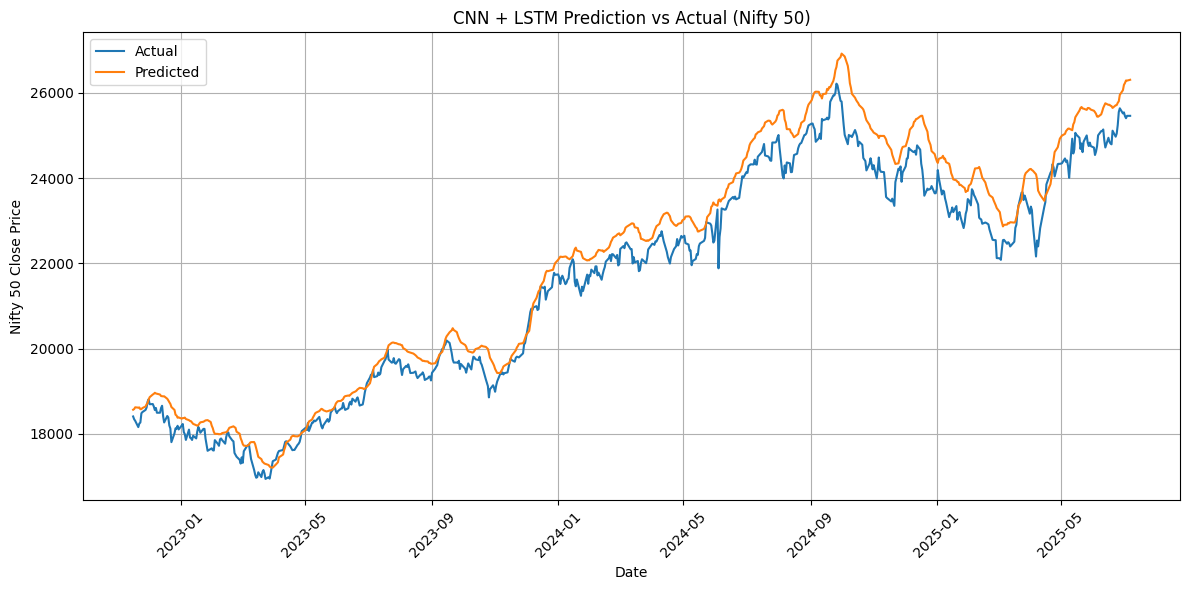

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Conv1D, MaxPooling1D, Dense, Dropout
import random
import tensorflow as tf

# SEED = 42
# np.random.seed(SEED)
# tf.random.set_seed(SEED)
# random.seed(SEED)


data = yf.download("^NSEI", start="2012-01-01", end="2025-07-08")[['Close']]
data.dropna(inplace=True)

# minmax normalization
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Close']])
scaled_df = pd.DataFrame(scaled_data, index=data.index, columns=['Close'])

# Create sequences with dates
def create_sequences(df, seq_len):
    X, y, dates = [], [], []
    for i in range(seq_len, len(df)):
        X.append(df.iloc[i-seq_len:i].values)
        y.append(df.iloc[i].values)
        dates.append(df.index[i])
    return np.array(X), np.array(y), dates

seq_len = 60
X, y, dates = create_sequences(scaled_df, seq_len)


split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
test_dates = dates[split:]

# Reshape for Keras input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# --- LSTM ---
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

# --- RNN ---
model_rnn = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

# --- CNN + LSTM ---
model_cnn_lstm = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    LSTM(64),
    Dense(1)
])
model_cnn_lstm.compile(optimizer='adam', loss='mse')
model_cnn_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)
model_cnn_lstm.save("nifty_cnn_lstm.h5")


def evaluate(model, name):
    preds = model.predict(X_test)
    preds_inv = scaler.inverse_transform(preds)
    actual_inv = scaler.inverse_transform(y_test)
    
    plt.figure(figsize=(12,6))
    plt.plot(test_dates, actual_inv, label='Actual')
    plt.plot(test_dates, preds_inv, label='Predicted')
    plt.title(f'{name} Prediction vs Actual (Nifty 50)')
    plt.xlabel("Date")
    plt.ylabel("Nifty 50 Close Price")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Evaluate all models
evaluate(model_lstm, "LSTM")
evaluate(model_rnn, "RNN")
evaluate(model_cnn_lstm, "CNN + LSTM")


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


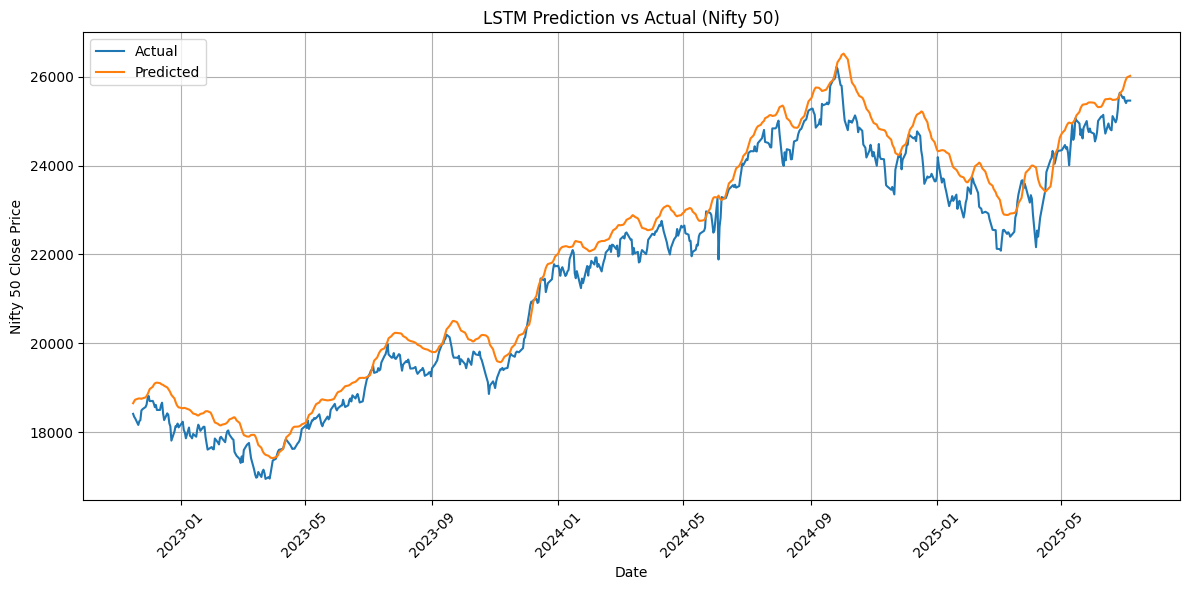

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


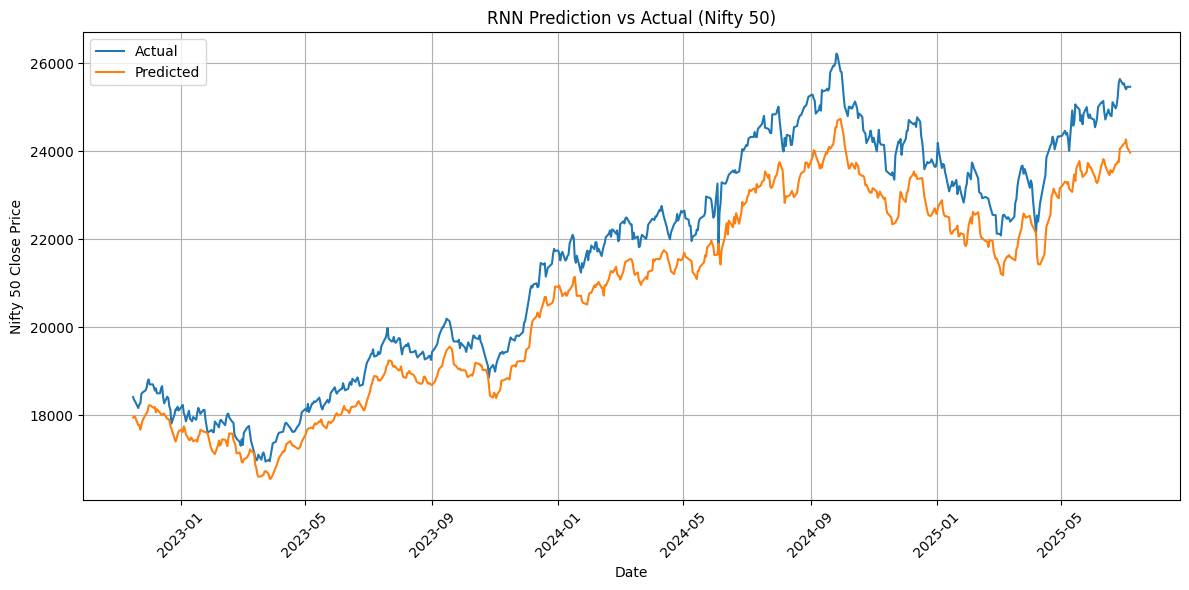

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


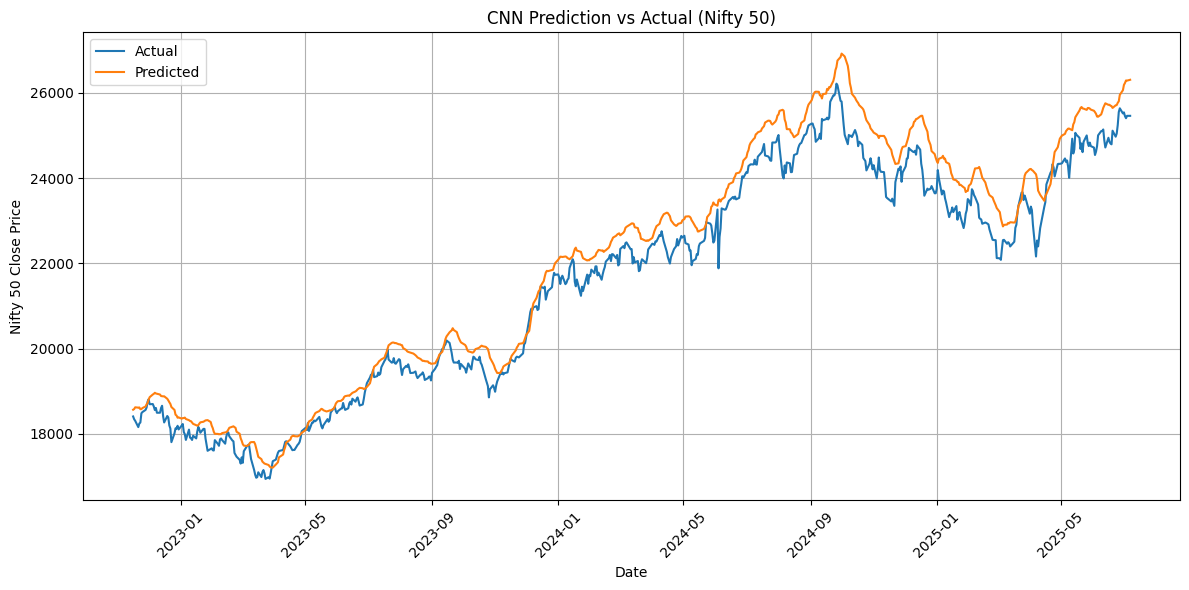

In [2]:
def evaluate(model, name):
    preds = model.predict(X_test)
    preds_inv = scaler.inverse_transform(preds)
    actual_inv = scaler.inverse_transform(y_test)
    
    plt.figure(figsize=(12,6))
    plt.plot(test_dates, actual_inv, label='Actual')
    plt.plot(test_dates, preds_inv, label='Predicted')
    plt.title(f'{name} Prediction vs Actual (Nifty 50)')
    plt.xlabel("Date")
    plt.ylabel("Nifty 50 Close Price")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Evaluate all models
evaluate(model_lstm, "LSTM")
evaluate(model_rnn, "RNN")
evaluate(model_cnn_lstm, "CNN")

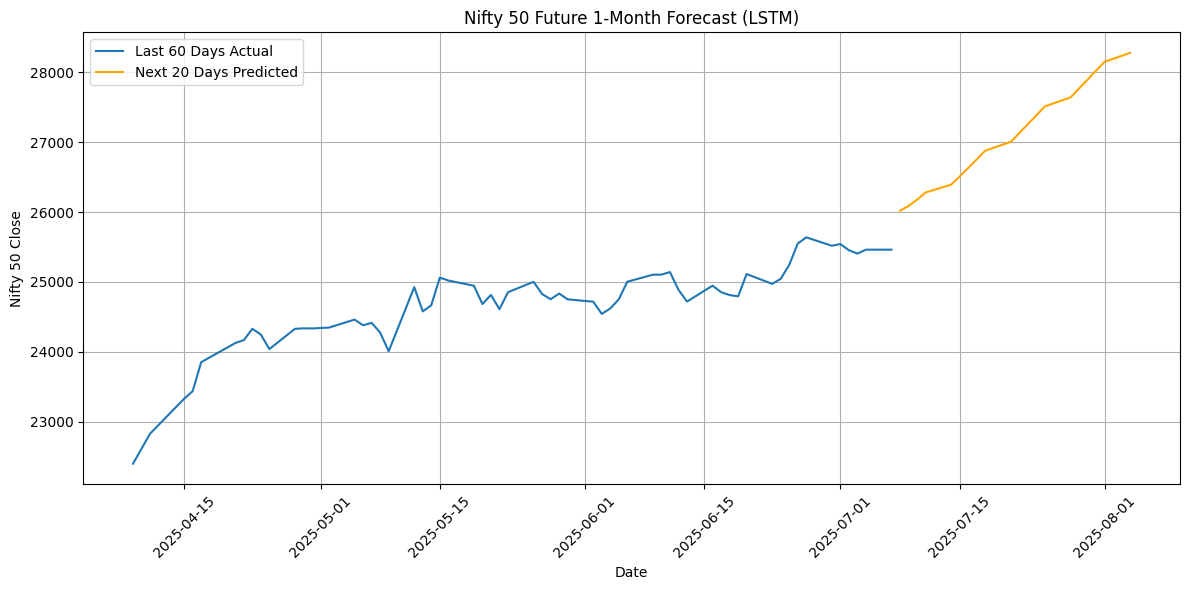

In [3]:
def predict_future(model, last_sequence, steps=20):
    future_preds = []
    current_seq = last_sequence.copy()
    
    for _ in range(steps):
        pred = model.predict(current_seq.reshape(1, current_seq.shape[0], 1), verbose=0)
        future_preds.append(pred[0, 0])
        
        # Append prediction and remove oldest to maintain sequence length
        current_seq = np.append(current_seq[1:], [[pred[0, 0]]], axis=0)
    
    return np.array(future_preds).reshape(-1, 1)

# Get the last sequence from the test set
last_seq = X_test[-1]

# Predict next 20 trading days
future_preds_scaled = predict_future(model_lstm, last_seq, steps=20)

# Inverse transform to original scale
future_preds = scaler.inverse_transform(future_preds_scaled)

# Generate future dates
from datetime import timedelta

last_date = test_dates[-1]
future_dates = pd.bdate_range(start=last_date + timedelta(days=1), periods=20)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(data.index[-60:], data['Close'].values[-60:], label='Last 60 Days Actual')
plt.plot(future_dates, future_preds, label='Next 20 Days Predicted', color='orange')
plt.title("Nifty 50 Future 1-Month Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Nifty 50 Close")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_metrics(model, X_test, y_test, name):
    preds = model.predict(X_test)
    preds_inv = scaler.inverse_transform(preds)
    actual_inv = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(actual_inv, preds_inv))
    mae = mean_absolute_error(actual_inv, preds_inv)
    mape = np.mean(np.abs((actual_inv - preds_inv) / actual_inv)) * 100
    r2 = r2_score(actual_inv, preds_inv)

    print(f"\n Accuracy Metrics for {name}:")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R²    : {r2:.4f}")


In [5]:
print_metrics(model_lstm, X_test, y_test, "LSTM")
print_metrics(model_rnn, X_test, y_test, "RNN")
print_metrics(model_cnn_lstm, X_test, y_test, "CNN")


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

 Accuracy Metrics for LSTM:
RMSE : 561.00
MAE  : 475.34
MAPE : 2.22%
R²    : 0.9541
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

 Accuracy Metrics for RNN:
RMSE : 951.25
MAE  : 877.92
MAPE : 3.95%
R²    : 0.8680
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

 Accuracy Metrics for CNN:
RMSE : 605.13
MAE  : 502.73
MAPE : 2.26%
R²    : 0.9466


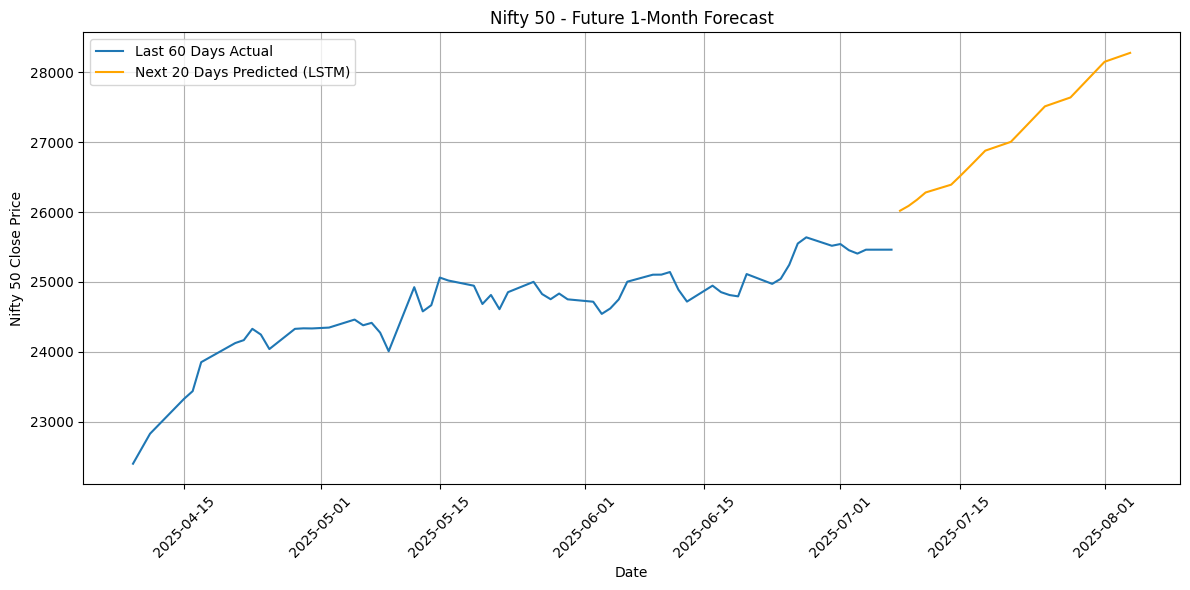

In [6]:
def predict_future(model, last_sequence, steps=20):
    future_preds = []
    current_seq = last_sequence.copy()
    
    for _ in range(steps):
        pred = model.predict(current_seq.reshape(1, current_seq.shape[0], 1), verbose=0)
        future_preds.append(pred[0, 0])
        current_seq = np.append(current_seq[1:], [[pred[0, 0]]], axis=0)
    
    return np.array(future_preds).reshape(-1, 1)

# Predict next 20 trading days using LSTM
last_seq = X_test[-1]
future_preds_scaled = predict_future(model_lstm, last_seq, steps=20)
future_preds = scaler.inverse_transform(future_preds_scaled)

from datetime import timedelta
future_dates = pd.bdate_range(start=test_dates[-1] + timedelta(days=1), periods=20)

# Plot future predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index[-60:], data['Close'].values[-60:], label='Last 60 Days Actual')
plt.plot(future_dates, future_preds, label='Next 20 Days Predicted (LSTM)', color='orange')
plt.title("Nifty 50 - Future 1-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Nifty 50 Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


// lets start with gdp

In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd


data = pd.read_csv("merged_gdp_features.csv")

# Select features and target
feature_cols = ['GDP_Growth', 'Imports_Pct_GDP', 'Exports_Pct_GDP', 'Inflation', 'USDINR']
target_col = 'GDP_USD'

# Drop missing rows (if any)
data = data.dropna()

# Scale input and target
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(data[feature_cols])
y_scaled = target_scaler.fit_transform(data[[target_col]])


In [8]:
# Combine features and target
scaled_data = np.hstack([X_scaled, y_scaled])

def create_sequences(data, seq_len=5):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(data)):
        X_seq.append(data[i-seq_len:i, :-1])  # inputs: features
        y_seq.append(data[i, -1])             # output: GDP target
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(scaled_data, seq_len=5)


In [9]:
print(X_seq.shape)  
print(y_seq.shape)  


(43, 5, 5)
(43,)


In [10]:
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

# Load pretrained CNN+LSTM model (replace path if needed)
# pretrained_model = load_model("nifty_encoder_model.h5")

# ----- OR: define architecture (if encoder file is not available) -----
input_layer = Input(shape=(5, 5))  # 5 years, 5 features
x = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
x = Dropout(0.2)(x)
x = LSTM(64, return_sequences=False)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='linear')(x)

model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 5, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 64)          │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,841 (140.00 KB)

 Trainable params: 35,841 (140.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Split into training and testing
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test))


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - loss: 0.0200 - mae: 0.0938 - val_loss: 0.2170 - val_mae: 0.4435
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0142 - mae: 0.1108 - val_loss: 0.1660 - val_mae: 0.3792
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0078 - mae: 0.0759 - val_loss: 0.2359 - val_mae: 0.4625
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0076 - mae: 0.0585 - val_loss: 0.1807 - val_mae: 0.3974
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0028 - mae: 0.0381 - val_loss: 0.0871 - val_mae: 0.2511
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0062 - mae: 0.0650 - val_loss: 0.0938 - val_mae: 0.2621
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0026 - mae: 0.0375 - val_loss: 0.1583 - val_mae: 0.3633
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0057 - mae: 0.0606 - val_loss: 0.1354 - val_mae: 0.3292
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0019 - mae:

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict on test data
y_pred = model.predict(X_test)

# Inverse scale to get real values
y_pred_real = target_scaler.inverse_transform(y_pred)
y_test_real = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
RMSE: 833939881457.92
MAE: 613074575562.38
R² Score: -4.1242


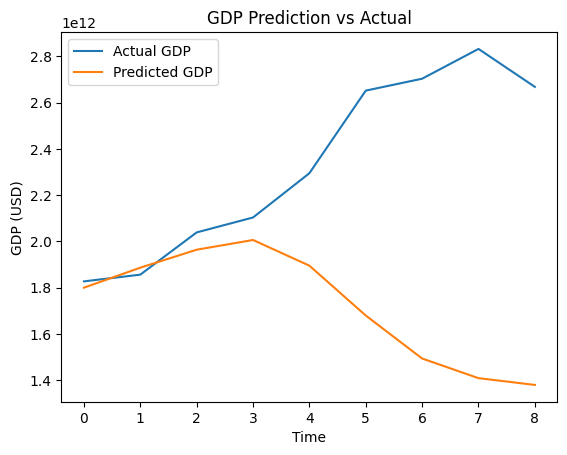

In [13]:
import matplotlib.pyplot as plt

plt.plot(y_test_real, label='Actual GDP')
plt.plot(y_pred_real, label='Predicted GDP')
plt.title('GDP Prediction vs Actual')
plt.xlabel('Time')
plt.ylabel('GDP (USD)')
plt.legend()
plt.show()


c:\Users\ASIS VIVOBOOJK\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.1810 - mae: 0.3667 - val_loss: 0.1604 - val_mae: 0.3989
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0247 - mae: 0.1137 - val_loss: 0.0023 - val_mae: 0.0345
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0144 - mae: 0.0995 - val_loss: 0.0383 - val_mae: 0.1920
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0050 - mae: 0.0569 - val_loss: 0.0407 - val_mae: 0.1981
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0077 - mae: 0.0639 - val_loss: 0.0040 - val_mae: 0.0510
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0029 - mae: 0.0429 - val_loss: 0.0031 - val_mae: 0.0412
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0024 - mae: 0.0407 - val_loss: 0.0060 - val_mae: 0.0674
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0031 - mae: 0.0460 - val_loss: 0.0016 - val_mae: 0.0335
Epoch 9/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0022 - mae:

C:\Users\ASIS VIVOBOOJK\AppData\Local\Temp\ipykernel_2232\1022966751.py:91: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASIS VIVOBOOJK\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


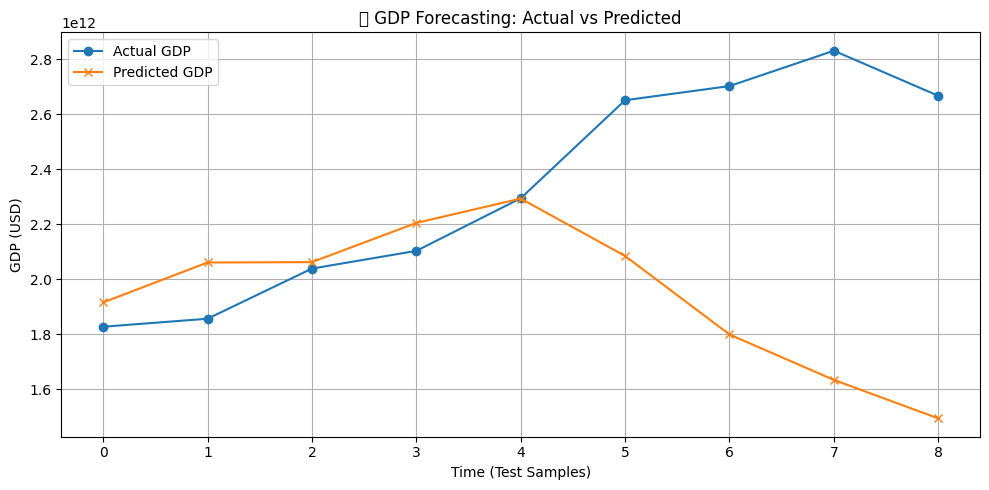

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ✅ Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1️⃣ Load and preprocess data
data = pd.read_csv("merged_gdp_features.csv")

# 👉 Log-transform the target (GDP)
data['GDP_log'] = np.log1p(data['GDP_USD'])  # log(1 + x) for stability

# Select features and target
feature_cols = ['GDP_Growth', 'Imports_Pct_GDP', 'Exports_Pct_GDP', 'Inflation', 'USDINR']
target_col = 'GDP_log'

# Drop missing values
data = data.dropna()

# Scale features and target separately
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(data[feature_cols])
y_scaled = target_scaler.fit_transform(data[[target_col]])

# 2️⃣ Create sequences
def create_sequences(X, y, seq_len=5):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

sequence_length = 5
X_seq, y_seq = create_sequences(X_scaled, y_scaled)

# 3️⃣ Split into train/test
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# 4️⃣ Define LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq.shape[1], X_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# 5️⃣ Train the model
history = model.fit(X_train, y_train, epochs=150, batch_size=4,
                    validation_data=(X_test, y_test), verbose=1)

# 6️⃣ Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions
y_pred_real = np.expm1(target_scaler.inverse_transform(y_pred))  # exp(log(x)) = x
y_test_real = np.expm1(target_scaler.inverse_transform(y_test))

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print(f"🔍 RMSE: {rmse:,.2f}")
print(f"🔍 MAE : {mae:,.2f}")
print(f"🔍 R²  : {r2:.4f}")

# 7️⃣ Plot predictions
plt.figure(figsize=(10, 5))
plt.plot(y_test_real, label='Actual GDP', marker='o')
plt.plot(y_pred_real, label='Predicted GDP', marker='x')
plt.title("📈 GDP Forecasting: Actual vs Predicted")
plt.xlabel("Time (Test Samples)")
plt.ylabel("GDP (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Prepare flat input (no sequences)
X = feature_scaler.fit_transform(data[feature_cols])
y = np.log1p(data['GDP_USD'])  # log-transform

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print(f"✅ RMSE: {rmse:,.2f}")
print(f"✅ R²  : {r2:.4f}")


✅ RMSE: 169,883,168,652.79
✅ R²  : 0.9491


In [16]:
# from tensorflow.keras.models import Model

# # Load your trained model
# full_model = tf.keras.models.load_model("nifty_cnn_lstm.h5")

# # Get encoder output
# encoder_model = Model(inputs=full_model.input, outputs=full_model.layers[-2].output)
# nifty_encoded = encoder_model.predict(nifty_X_seq)  # shape = (n, features)


In [24]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("LSTM expects:", model_lstm.input_shape)
print("RNN expects:", model_rnn.input_shape)
print("CNN-LSTM expects:", model_cnn_lstm.input_shape)

X_train shape: (38, 5, 1)
X_test shape: (10, 5, 1)
y_train shape: (38,)
y_test shape: (10,)
LSTM expects: (None, 60, 1)
RNN expects: (None, 60, 1)
CNN-LSTM expects: (None, 60, 1)


In [28]:
def evaluate1(model, name):
    preds = model.predict(X_test, verbose=0)
    preds_inv = scaler.inverse_transform(preds).flatten()

    y_test_2d = np.array(y_test).reshape(-1, 1)
    actual_inv = scaler.inverse_transform(y_test_2d).flatten()
    
    daily_diff = preds_inv - actual_inv
    
    total_return = np.sum(daily_diff)
    average_return = np.mean(daily_diff)
    
    print(f"\n{name} Results:")
    print(f"Total Return (sum of predicted - actual): {total_return:.2f}")
    print(f"Average Return (mean of predicted - actual): {average_return:.2f}")
    
    plt.figure(figsize=(12,6))
    plt.plot(test_dates, actual_inv, label='Actual')
    plt.plot(test_dates, preds_inv, label='Predicted')
    plt.title(f'{name} Prediction vs Actual (Nifty 50)')
    plt.xlabel("Date")
    plt.ylabel("Nifty 50 Close Price")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


LSTM Results:
Total Return (sum of predicted - actual): -5721499.02
Average Return (mean of predicted - actual): -572149.90


ValueError: x and y must have same first dimension, but have shapes (652,) and (10,)

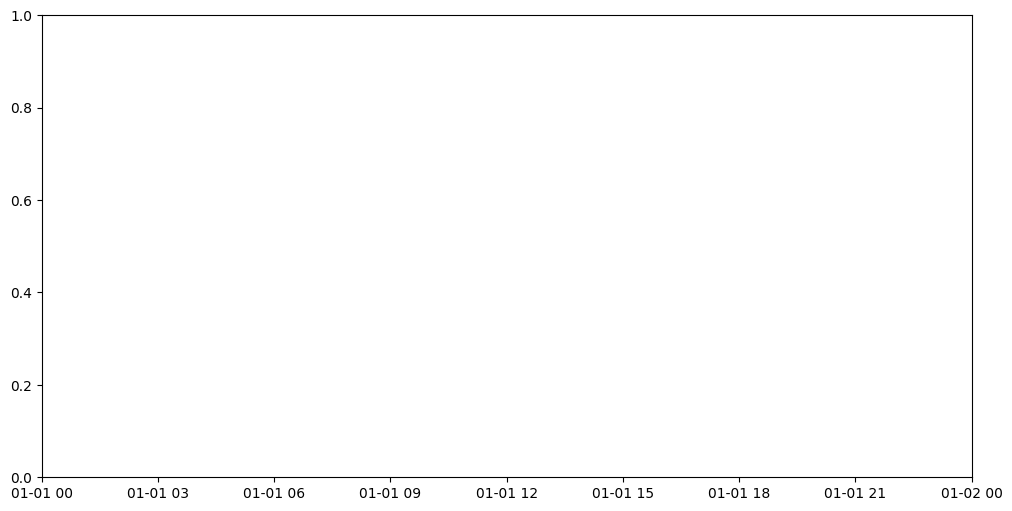

In [29]:
# if len(X_train.shape) == 2:
#     X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# if len(X_test.shape) == 2:
#     X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
evaluate1(model_lstm, "LSTM")
evaluate1(model_rnn, "RNN")
evaluate1(model_cnn_lstm, "CNN + LSTM")